# Titanic Data Analysis
## Feature Engineering
- *Goal: Transform data into predictive features*

In [3]:
# Import of the relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic_Train.csv')
print('--Data Load--')

--Data Load--


In [4]:
# Starting with the raw data file and checking the basics - head information
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [5]:
# Checking the columns
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [6]:
# Checking for missing values with isna().sum()
print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Note:** I will not fill the Age missing values with the mean, like in the EDA file before. And I will also keep the missing value column 'Cabin' and also the two missing rows in 'Embarked'.

In [7]:
# Extracting the title in the name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Checking the values
print(df['Title'].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']


In [8]:
#replacing the french title and change it to english title
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'] = df['Title'].replace('Ms', 'Miss')

#checking the 'Title' column
print(df['Title'].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Major' 'Lady' 'Sir' 'Col'
 'Capt' 'Countess' 'Jonkheer']


In [9]:
#replacing some specific titles 
rare_title =['Don', 'Rev', 'Dr', 'Major', 'Lady', 'Sir', 'Col', 'Capt', 'Countess', 'Jonkheer']
df['Title'] = df['Title'].replace(rare_title, 'Rare')

#checking the 'Title' column
print(df['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


*Note: Changed some special title into the most comun title like Mr, Miss, Mrs und Master, all other changed to rare. After that I can change the missing age values, because with the title it is more clear in which age range they are instead of the median.*

In [10]:
#adding the missing age values by median age based on each title group
df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))

#checking for missing age values
print(df['Age'].isna().sum())

0


*Note: I added based on the title group the median age for the missing age values.*

In [11]:
#filling the two missing embarked values with the most frquent embarked value
most_freq_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_freq_embarked)
#checking the values
print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Title            0
dtype: int64


In [12]:
#addind new column 'FamilySize'
df['FamilySize'] = df['SibSp'] + df['Parch'] +1
#checkin the values
print(df['FamilySize'].describe())

count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64


**Note:** I added a new column 'FamilySize' to check later, how the survival rate changed comparing to the size of family and also to check it there is a relationship between survival rate and family size

In [13]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize'],
      dtype='object')

In [14]:
#adding new column 'isAlone'
df['isAlone'] = 0

df.loc[df['FamilySize'] == 1, 'isAlone'] = 1
#checking the values
print(df['isAlone'].describe())

count    891.000000
mean       0.602694
std        0.489615
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: isAlone, dtype: float64


**Note:** I added a new column 'isAlone' - binary feature to indicate whether a passenger was traveling alone or with family members. A value of 1 'True' represented passengers traveling alone, while 0 'False' represents passengers traveling with at least one family member. This feature is used to examine whether traveling alone has an impact on survival rate.

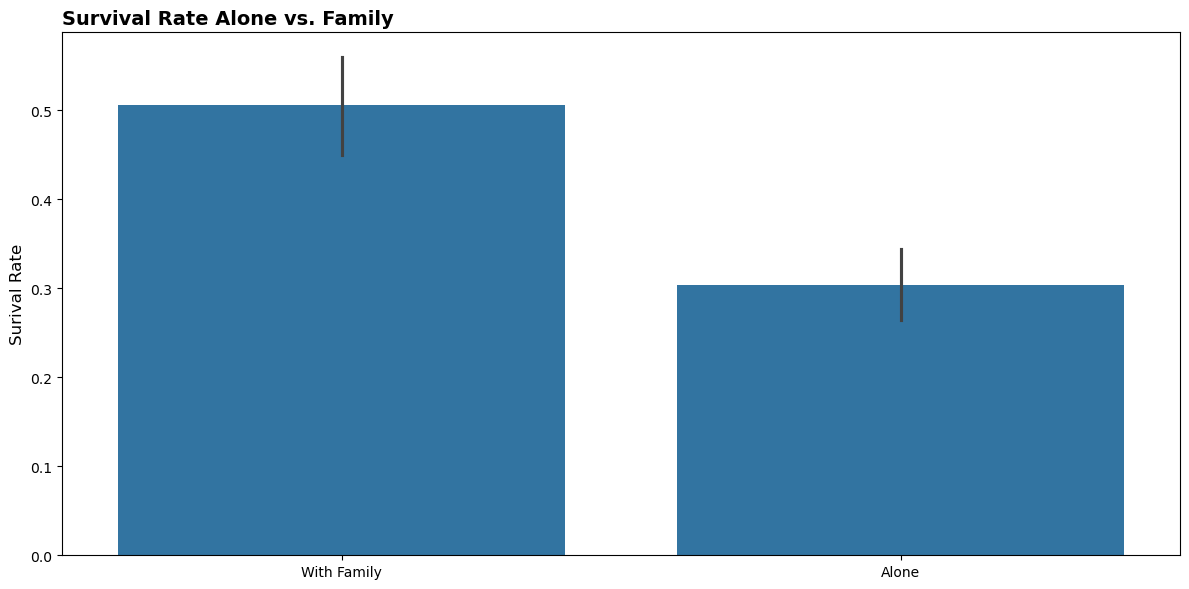

In [15]:
#visualize the survival rate alone vs family

plt.figure(figsize=(12,6))

ax = sns.barplot(data=df, x='isAlone', y='Survived')
ax.set_xticks([0,1])
ax.set_title('Survival Rate Alone vs. Family', fontsize=14, fontweight='bold', loc='left')
ax.set_xlabel('')
ax.set_ylabel('Surival Rate', fontsize=12)
ax.set_xticklabels(['With Family', 'Alone'])

plt.tight_layout()
plt.show()

The chart reveals that the survival rate for passengers traveling with family is significant higher than for those traveling alone.<br>
**Hypothesis:**
- **Mutual Support:** Families likey supported each other during the abandon ship scenario and making sure everyone reached the life boats
- **Priority:** Women and children, who were prioritiyed during the lifeboat evacuation, were mostly traveling within a family structure.
- **Isolation:** Passengers traveling alone lacked a support network on board and were not the first priority

In [16]:
#preparing column 'sex' and column 'embarked' with pd.get_dummies and convert the data
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=False, dtype=int)

#checking the columns
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Title', 'FamilySize', 'isAlone',
       'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


**Note:** One-Hot-Encoding - replaced the column 'sex' into 'sex_male' which means 0 is woman and 1 is man. The column 'Embarked' if there are two 0 the embarked port is C - Cherbourg.

In [17]:
#adding a new column 'AgeGroup' with pd.cut and separate the passengers into comun age Groups
age_groups = [0, 12, 19, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=age_groups, labels=age_labels)

#checking the values
print(df['AgeGroup'].value_counts())

AgeGroup
Young Adult    505
Adult          196
Teen            95
Child           73
Senior          22
Name: count, dtype: int64


**Note:** Added a new column 'AgeGroup' and assigned each passenger to a group with the corresponding values

In [18]:
#adding another new column for fair tickets and separte that into groups, now using pd.qcut
df['FareCategory'] = pd.qcut(df['Fare'], q=4, labels=['Cheap', 'Medium', 'Expensive', 'Luxury'])

#checking the values
print(df['FareCategory'].value_counts())
print(pd.qcut(df['Fare'], q=4).value_counts())

FareCategory
Medium       224
Cheap        223
Expensive    222
Luxury       222
Name: count, dtype: int64
Fare
(7.91, 14.454]     224
(-0.001, 7.91]     223
(14.454, 31.0]     222
(31.0, 512.329]    222
Name: count, dtype: int64


**Note:** Added FareCategory as new column and each fare price is assigned to a category.

In [19]:
#adding new column 'hasCabin'
df['hasCabin'] = df['Cabin'].notna().astype(int)

#checking the values
print(df['hasCabin'].value_counts())

hasCabin
0    687
1    204
Name: count, dtype: int64


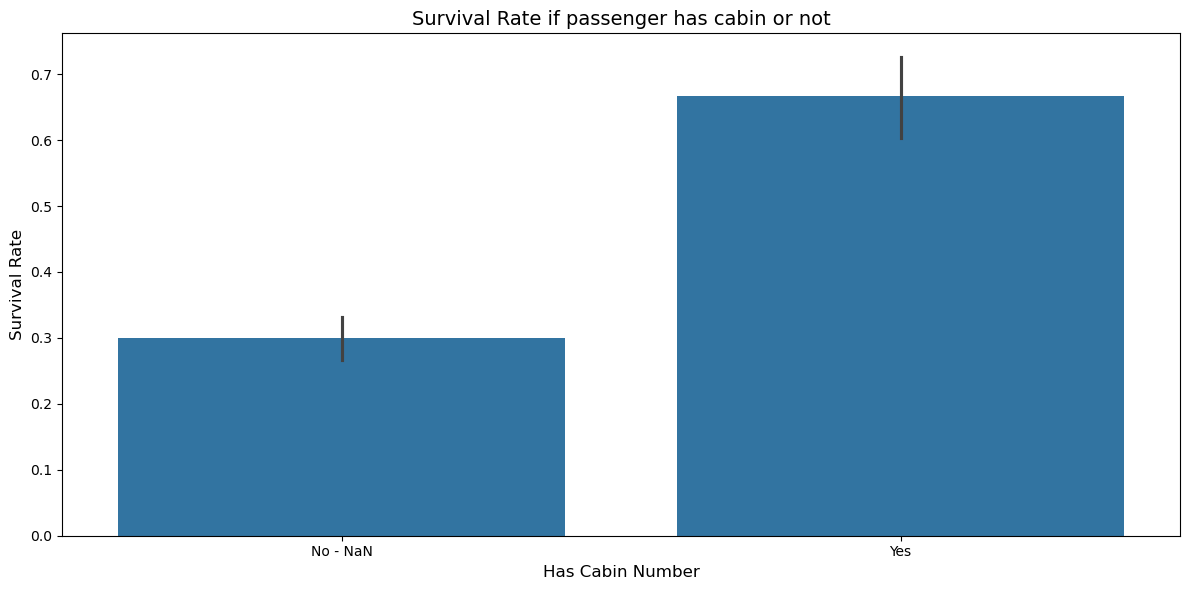

In [20]:
#visualize the survival rate by 'hasCabin'
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='hasCabin', y='Survived')
plt.title('Survival Rate if passenger has cabin or not', fontsize=14)
plt.xlabel('Has Cabin Number', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.xticks([0, 1], ['No - NaN', 'Yes'])

plt.tight_layout()
plt.show()

The chart reveals that passenger which had a cabin number has a higher survival rate than passengers without a designated cabin number. Which indicates, that passengers with a designated cabin number on their ticket are most likely first or second class, while passenger traveling in third class were sleeping in shared cabins without a designated cabin number. 

In [21]:
#changing columns 'Titel', 'AgeGroup' and 'FareCategory' to binary values
df = pd.get_dummies(df, columns=['Title', 'FareCategory', 'AgeGroup'], drop_first=False, dtype=int)

#checking the columns
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'FamilySize', 'isAlone', 'Sex_female',
       'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'hasCabin',
       'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare',
       'FareCategory_Cheap', 'FareCategory_Medium', 'FareCategory_Expensive',
       'FareCategory_Luxury', 'AgeGroup_Child', 'AgeGroup_Teen',
       'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior'],
      dtype='object')


**Note on One-Hot Encoding (`drop_first=True`):** By dropping the first category of each encoded column to prevent multicollinearity, the "baseline" (where all remaining columns are `0`) represents: <br>
- **Title:** A `0` in all remaining title columns indicates the title was **'Master'**.
- **FareCategory:** A `0` in all fare categories indicates the category was **'Cheap'**.
- **AgeGroups:** A `0` in all age groups indicates the group was **'Child'**.

In [22]:
#drop columns which are not longer needed for ML mode, because the cells include strings
columns_to_drop = ['PassengerId', 'Name', 'Age', 'Ticket', 'Fare', 'Cabin']
df_ml = df.drop(columns=columns_to_drop)

#checking the columns
print(df_ml.columns)
df_ml.head()

Index(['Survived', 'Pclass', 'SibSp', 'Parch', 'FamilySize', 'isAlone',
       'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'hasCabin', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Rare', 'FareCategory_Cheap', 'FareCategory_Medium',
       'FareCategory_Expensive', 'FareCategory_Luxury', 'AgeGroup_Child',
       'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult',
       'AgeGroup_Senior'],
      dtype='object')


,Survived,Pclass,SibSp,Parch,FamilySize,isAlone,Sex_female,Sex_male,Embarked_C,Embarked_Q,...,Title_Rare,FareCategory_Cheap,FareCategory_Medium,FareCategory_Expensive,FareCategory_Luxury,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior
0,0,3,1,0,2,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
1,1,1,1,0,2,0,1,0,1,0,...,0,0,0,0,1,0,0,0,1,0
2,1,3,0,0,1,1,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,1,1,1,0,2,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,0,3,0,0,1,1,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0


**Note:** Now the whole table is binary, which is the base for the ML

In [23]:
#Saving as a new file
df_ml.to_csv('Titanic_for_ML.csv', index=False)